In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
from sqlalchemy import create_engine
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')


# Loading the dataset

In [2]:
engine = create_engine('mysql+pymysql://root:<password>@localhost:3306/inventorydb')


In [3]:
df = pd.read_sql('select * from vendor_sales_summary', engine)
df

,VendorNumber,VendorName,Brand,ActualPrice,Volume,PurchasePrice,Description,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalPurchaseQuantity,TotalPurchaseDollars,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPucharseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,36.99,750.0,23.86,Ch Lilian 09 Ladouys St Este,14,517.86,221.94,1.56,328,5630.88,27.08,-5113.02,-987.34,0.04,0.09
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,24.99,162.5,17.00,Flavor Essence Variety 5 Pak,24,599.76,449.82,0.52,328,5630.88,27.08,-5031.12,-838.86,0.07,0.11
2,54,AAPER ALCOHOL & CHEMICAL CO,990,134.49,3750.0,105.07,0,0,0.00,0.00,0.00,1,105.07,0.48,-105.07,0.00,0.00,0.00
3,60,ADAMBA IMPORTS INTL INC,771,14.99,750.0,11.44,Bak's Krupnik Honey Liqueur,6,89.94,74.95,4.73,4732,76770.25,367.52,-76680.31,-85257.18,0.00,0.00
4,60,ADAMBA IMPORTS INTL INC,3401,14.99,1750.0,11.10,0,0,0.00,0.00,0.00,4732,76770.25,367.52,-76770.25,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12256,172662,SWEETWATER FARM,4215,25.99,750.0,19.40,Kingfish Silver Rum,72,1871.28,1507.42,56.78,1629,34708.03,178.34,-32836.75,-1754.77,0.04,0.05
12257,173357,TAMWORTH DISTILLING,2804,44.99,750.0,32.14,0,0,0.00,0.00,0.00,1990,41036.44,202.50,-41036.44,0.00,0.00,0.00
12258,173357,TAMWORTH DISTILLING,3666,24.99,375.0,18.79,Art in the Age Chicory Root,157,3923.43,1649.34,61.63,1990,41036.44,202.50,-37113.01,-945.93,0.08,0.10
12259,173357,TAMWORTH DISTILLING,3848,30.99,750.0,23.30,0,0,0.00,0.00,0.00,1990,41036.44,202.50,-41036.44,0.00,0.00,0.00


# Exploratory Data Analysis
* Previously, we examined the various tables in the identity key variables, understand their relationships, and determine which ones should be included in the final analysis.
* In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identity anomalies, and ensure data quantity before processing with futher analysis

In [4]:
# summary statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,12261.0,1.081486e+04,1.900768e+04,2.000000e+00,3960.00,7153.00,9552.00,173357.00
Brand,12261.0,1.798907e+04,1.252850e+04,5.800000e+01,5990.00,18788.00,25117.00,90631.00
ActualPrice,12261.0,3.864024e+01,2.061512e+02,0.000000e+00,10.99,15.99,29.99,13999.90
Volume,12261.0,8.425777e+02,6.796042e+02,0.000000e+00,750.00,750.00,750.00,20000.00
PurchasePrice,12261.0,2.648822e+01,1.561829e+02,0.000000e+00,6.89,10.65,20.13,11111.03
TotalSalesQuantity,12261.0,1.247892e+03,4.945161e+03,0.000000e+00,2.00,48.00,598.00,168535.00
TotalSalesDollars,12261.0,1.692450e+04,7.215611e+04,0.000000e+00,44.94,1070.37,9653.93,2331607.93
TotalSalesPrice,12261.0,7.846537e+03,2.129976e+04,0.000000e+00,13.96,527.40,5353.09,353063.52
TotalExciseTax,12261.0,7.262305e+02,4.835995e+03,0.000000e+00,0.33,7.95,124.25,183418.84
TotalPurchaseQuantity,12261.0,1.246762e+06,1.233287e+06,0.000000e+00,352526.00,1006122.00,1858260.00,5459788.00


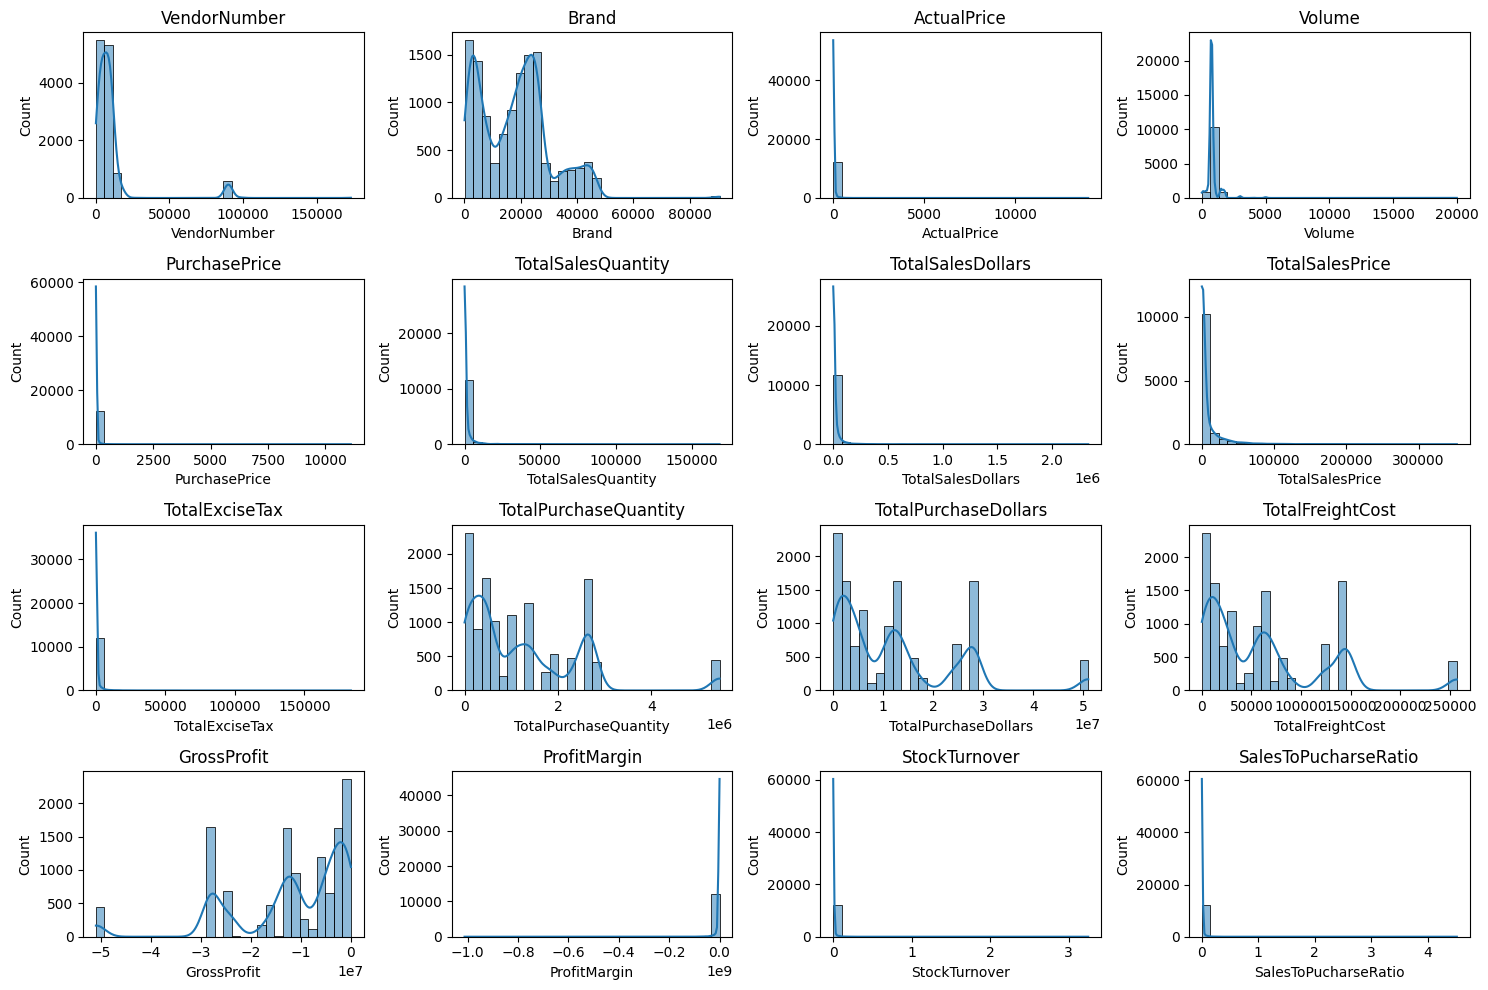

In [5]:
# Disribution plots for numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)                # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

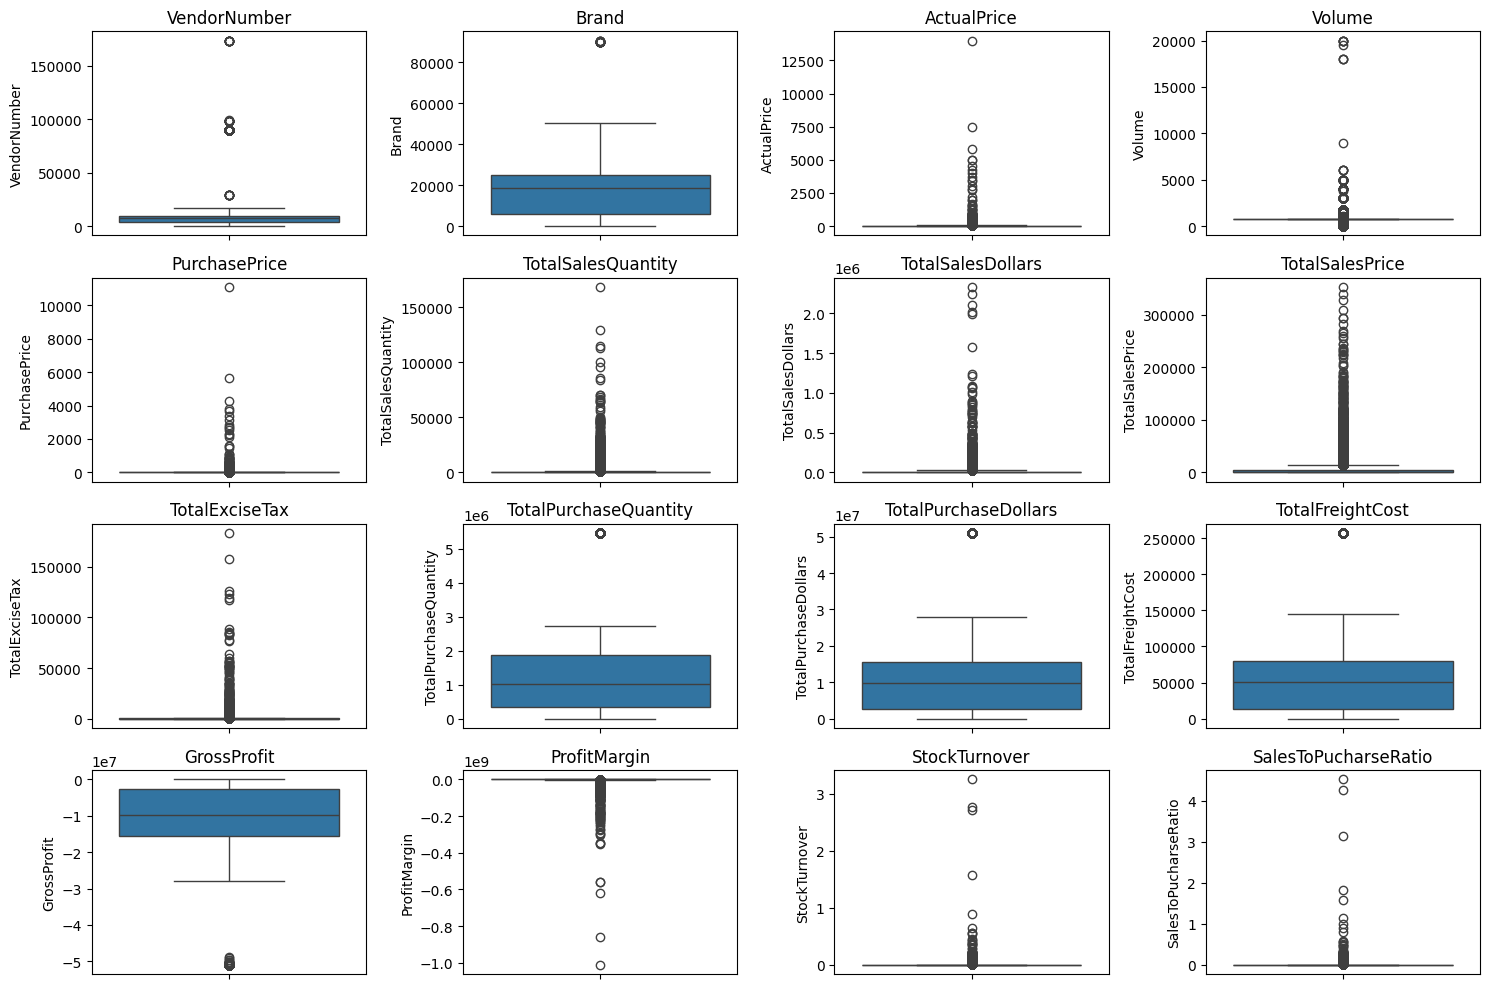

In [6]:
# Oulier Detection with Boxplots
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [7]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'ActualPrice', 'Volume',
       'PurchasePrice', 'Description', 'TotalSalesQuantity',
       'TotalSalesDollars', 'TotalSalesPrice', 'TotalExciseTax',
       'TotalPurchaseQuantity', 'TotalPurchaseDollars', 'TotalFreightCost',
       'GrossProfit', 'ProfitMargin', 'StockTurnover', 'SalesToPucharseRatio'],
      dtype='object')

In [8]:
df['StockTurnover'].max()

np.float64(3.25)

# Summary Statistics Insights

Negative & Zero Values:
* Gross Profit: Minimum value is -50959796.85, indicating losses. Some products or transaction may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
* Profit Margin: Has a minimum of -1011915232.65, which sugest cases where revenue is zero or even lower thab costs.
* Total Sale Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

# Outliers Indicated by High Standard Deviation:
* Purchase & Actual prices: The max value 11111.03 & 13999.9 are significantly higher than the mean (26.488219557947964 & 38.640239784683146), including potential premium products.
* Freight Cost: Ranges from 0 to 257032.07, suggests logistics ineffiecies or bulk shipments.
* Stock Turnover: Ranges from 0 to 3.25, implying sell extremely fast while others remain in indefinitely. Value more than 1 indicates that Sold quantity for that products is higher than purchased quantity due to either sales are being fullfiled from older stock

In [9]:
# let's filter the data by removing inconsistencies
df = pd.read_sql('''SELECT *
    FROM vendor_sales_summary
    WHERE GrossProfit > 0
    AND ProfitMargin > 0
    AND TotalSalesQuantity > 0 
''', engine)

In [38]:
df

,VendorNumber,VendorName,Brand,ActualPrice,Volume,PurchasePrice,Description,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalPurchaseQuantity,TotalPurchaseDollars,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPucharseRatio
0,1002,BERNIKO LLC,4015,16.99,750.0,12.87,Ron Fortuna 8 Yr Old Rum,1,16.99,16.99,0.79,0,0.00,0.00,16.99,100.00,0.00,0.00
1,1439,CAPSTONE INTERNATIONAL,2213,26.99,1750.0,13.66,King Robert II Scotch Whisky,13,246.87,113.94,23.89,4,54.64,0.27,192.23,77.87,3.25,4.52
2,2396,BLACK PRINCE DISTILLERY INC,3079,15.99,750.0,10.21,Devils Spring Vodka,717,9360.83,5280.05,564.81,807,5971.94,30.98,3388.89,36.20,0.89,1.57
3,8663,STAR INDUSTRIES INC.,2193,24.99,750.0,16.41,Donegal Irish Whiskey,411,7716.89,4430.65,323.87,151,2452.29,12.44,5264.60,68.22,2.72,3.15
4,9710,WHYTE & MACKAY,2539,19.99,1750.0,12.30,John Barr Red Scotch Whisky,2,31.98,15.99,3.67,0,0.00,0.00,31.98,100.00,0.00,0.00
5,9751,VINEDREA WINES LLC,1542,29.99,750.0,22.72,Bowen's American Whiskey,323,8461.77,6397.58,254.74,205,4657.60,24.53,3804.17,44.96,1.58,1.82
6,90026,SILVER MOUNTAIN CIDERS,46327,6.99,650.0,4.54,Silver Mtn Hard Cider,47,328.53,202.71,4.64,17,77.18,0.36,251.35,76.51,2.76,4.26
7,90034,EXCLUSIVE WINES & SPIRITS,15625,27.99,750.0,18.54,Mourvedre Bunnell Family,2,55.98,27.99,0.22,0,0.00,0.00,55.98,100.00,0.00,0.00
8,90037,THE PIERPONT GROUP LLC,2163,24.99,750.0,14.38,Sloane's Gin,322,6511.78,4107.98,253.84,580,5713.19,27.98,798.59,12.26,0.56,1.14


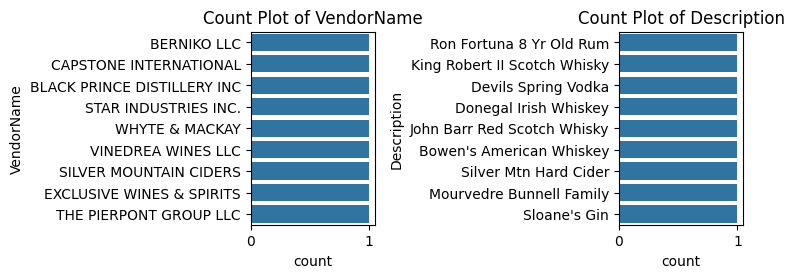

In [10]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

plt.figure(figsize=(15,10))

for i, col in enumerate(categorical_cols):
    plt.subplot(4, 4, i+1)
    sns.countplot(data=df, y=col, order=df[col].value_counts().index[:10])
    plt.title(f"Count Plot of {col}")

plt.tight_layout()
plt.show()

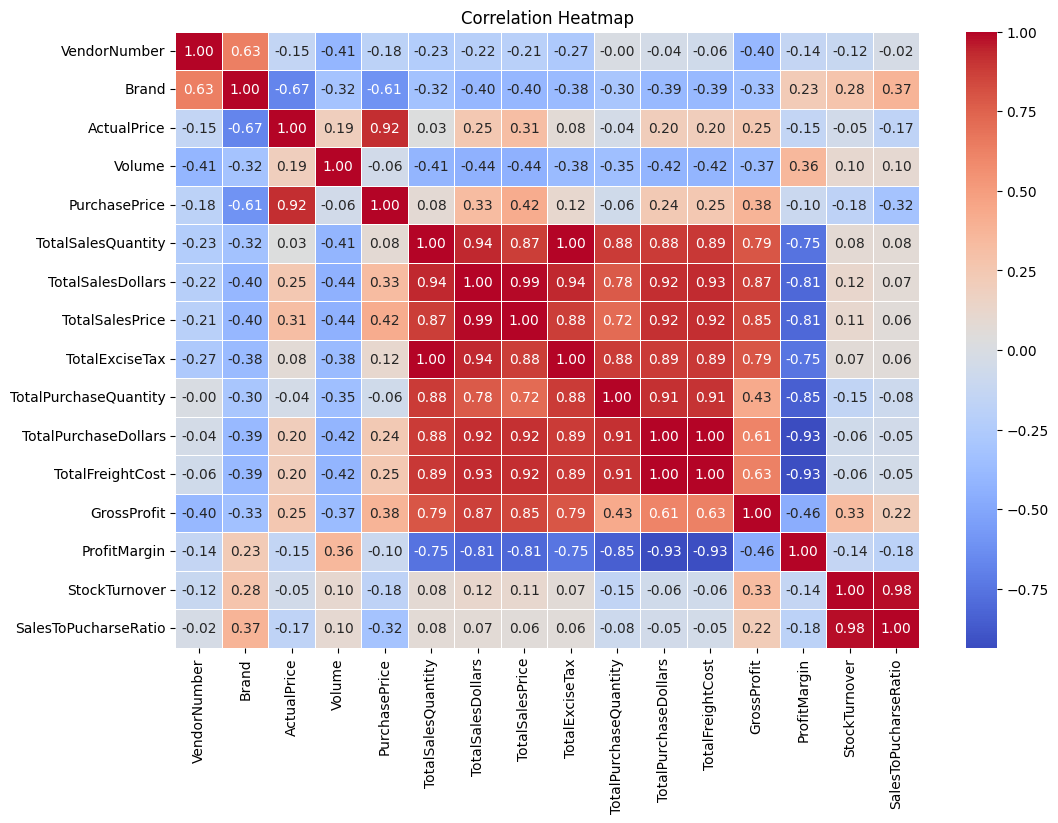

In [11]:
# Correlation Heatmap
plt.figure(figsize = (12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot= True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Correlation Insights
* PurchasePrice has weak correlation with TotalSalesDollars (0.33) and GrossProfit (0.38), suggesting that price variations do not significantly impact sales revenue or profit
* Strong correlation between total purchase quantity and total sales quantity (0.88 – 0.94), confirming efficient inventory turnover
* Negative correlation between profit margin (-0.93) & total sales price (-0.81) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures
* StockTurnover has weak correlation with both GrossProfit (0.33) and ProfitMargin (-0.14), indicating that faster turnover does not necessarily result in higher profitability

# Reseach Problem Questions

Identify Brands that needs Promotional or Pricing Adjustments which exhibit lower saless performance but higher profit margins.

In [12]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin':'mean'}).reset_index()

In [13]:
brand_performance 

,Description,TotalSalesDollars,ProfitMargin
0,Bowen's American Whiskey,8461.77,44.96
1,Devils Spring Vodka,9360.83,36.20
2,Donegal Irish Whiskey,7716.89,68.22
3,John Barr Red Scotch Whisky,31.98,100.00
4,King Robert II Scotch Whisky,246.87,77.87
5,Mourvedre Bunnell Family,55.98,100.00
6,Ron Fortuna 8 Yr Old Rum,16.99,100.00
7,Silver Mtn Hard Cider,328.53,76.51
8,Sloane's Gin,6511.78,12.26


In [14]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [15]:
low_sales_threshold

np.float64(36.78)

In [16]:
high_margin_threshold

np.float64(100.0)

In [17]:
# filter brands with low sales but high profit margins
target_brands = brand_performance [
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
    ]
print("Brands with low sales but High Profit Margin")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low sales but High Profit Margin


,Description,TotalSalesDollars,ProfitMargin
6,Ron Fortuna 8 Yr Old Rum,16.99,100.0
3,John Barr Red Scotch Whisky,31.98,100.0


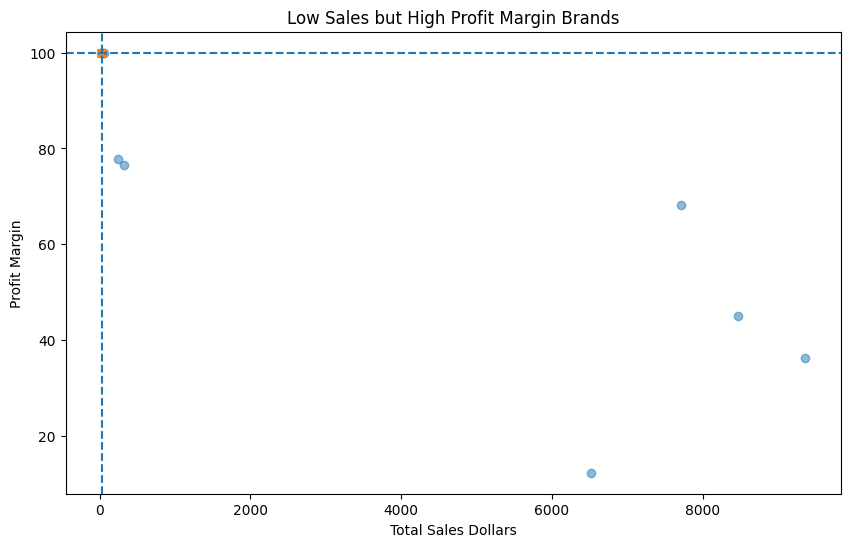

In [18]:
plt.figure(figsize=(10,6))

# All data
plt.scatter(
    brand_performance['TotalSalesDollars'],
    brand_performance['ProfitMargin'],
    alpha=0.5
)

# Highlight target brands
plt.scatter(
    target_brands['TotalSalesDollars'],
    target_brands['ProfitMargin'],
    marker='x'
)

# Threshold lines
plt.axvline(low_sales_threshold, linestyle='--')
plt.axhline(high_margin_threshold, linestyle='--')

plt.xlabel("Total Sales Dollars")
plt.ylabel("Profit Margin")
plt.title("Low Sales but High Profit Margin Brands")

plt.show()

In [19]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<1000]   # for better visualization

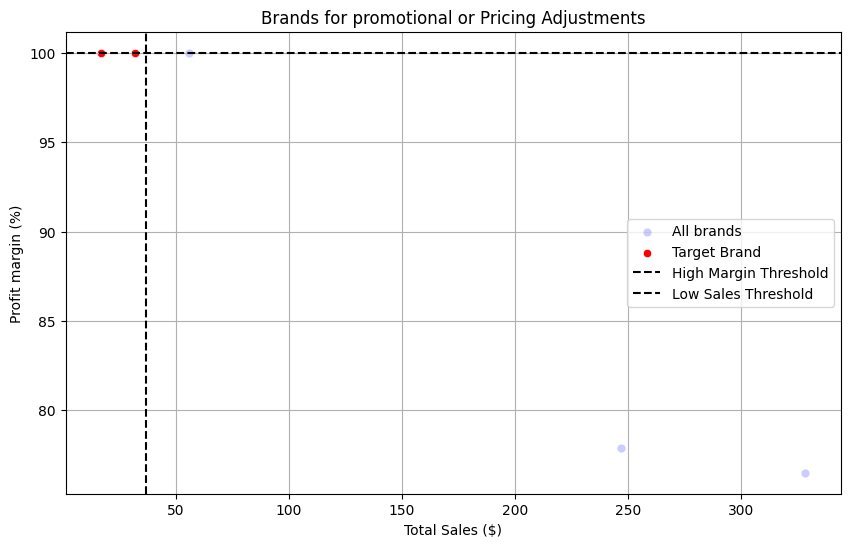

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(data = brand_performance, x = 'TotalSalesDollars' , y = 'ProfitMargin' , color = 'blue' , label = 'All brands' , alpha = 0.2 )
sns.scatterplot(data = target_brands, x = 'TotalSalesDollars' , y = 'ProfitMargin' , color = 'red' , label = 'Target Brand' )

plt.axhline(high_margin_threshold, linestyle = '--' , color = 'black' , label = 'High Margin Threshold')
plt.axvline(low_sales_threshold, linestyle = '--', color = 'black' , label = 'Low Sales Threshold')

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit margin (%)")
plt.title("Brands for promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

Which vendors and brands demonstrate the highest sales performance?

In [21]:
# Top vendors and Brands by Sales Performance

top_vendors = df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_vendors

VendorName
BLACK PRINCE DISTILLERY INC    9360.83
VINEDREA WINES LLC             8461.77
STAR INDUSTRIES INC.           7716.89
THE PIERPONT GROUP LLC         6511.78
SILVER MOUNTAIN CIDERS          328.53
CAPSTONE INTERNATIONAL          246.87
EXCLUSIVE WINES & SPIRITS        55.98
WHYTE & MACKAY                   31.98
BERNIKO LLC                      16.99
Name: TotalSalesDollars, dtype: float64

In [22]:
top_brands = df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)
top_brands

Description
Devils Spring Vodka             9360.83
Bowen's American Whiskey        8461.77
Donegal Irish Whiskey           7716.89
Sloane's Gin                    6511.78
Silver Mtn Hard Cider            328.53
King Robert II Scotch Whisky     246.87
Mourvedre Bunnell Family          55.98
John Barr Red Scotch Whisky       31.98
Ron Fortuna 8 Yr Old Rum          16.99
Name: TotalSalesDollars, dtype: float64

In [23]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [24]:
top_brands.apply(lambda x : format_dollars(x))

Description
Devils Spring Vodka              9.36K
Bowen's American Whiskey         8.46K
Donegal Irish Whiskey            7.72K
Sloane's Gin                     6.51K
Silver Mtn Hard Cider           328.53
King Robert II Scotch Whisky    246.87
Mourvedre Bunnell Family         55.98
John Barr Red Scotch Whisky      31.98
Ron Fortuna 8 Yr Old Rum         16.99
Name: TotalSalesDollars, dtype: object

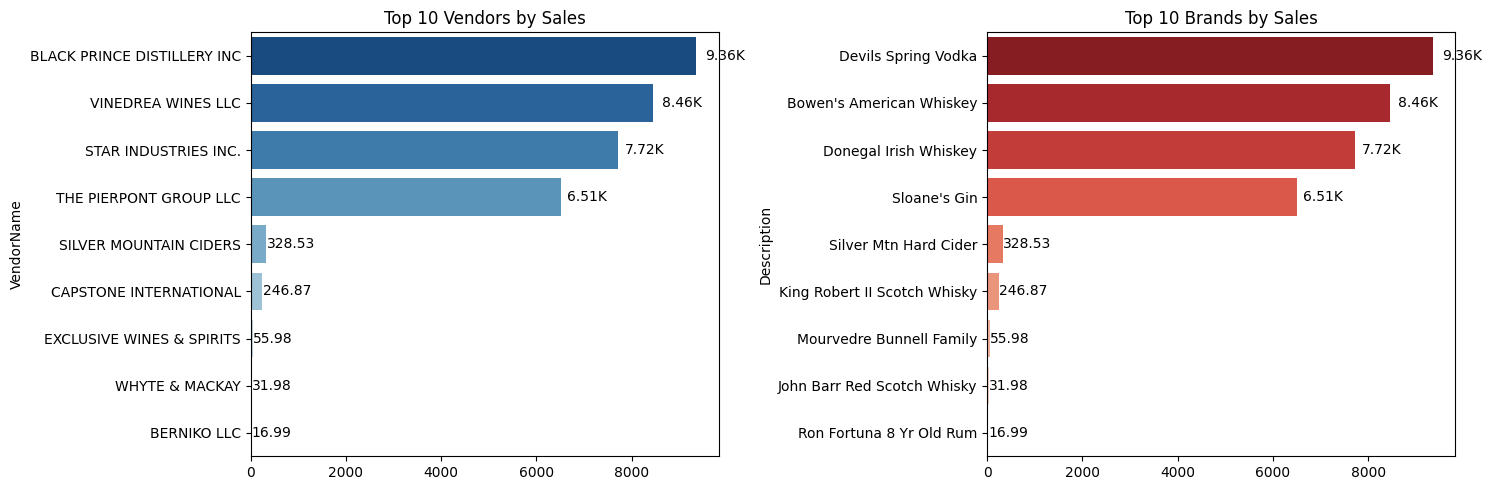

In [25]:
plt.figure(figsize=(15,5))

# Plot for Top Vendors
plt.subplot(1,2,1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette='Blues_r')
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left', va='center', fontsize=10, color='black'
    )

# Plot for Top Brands
plt.subplot(1,2,2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette='Reds_r')
plt.title('Top 10 Brands by Sales')

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left', va='center', fontsize=10, color='black'
    )

plt.tight_layout()
plt.show()

Which vendors contribute the most to total purchase dolars?

In [26]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
})

In [27]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum()

In [28]:
round(vendor_performance.sort_values('PurchaseContribution%', ascending=False),2)

,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
VendorName,,,,
BLACK PRINCE DISTILLERY INC,5971.94,3388.89,9360.83,0.32
THE PIERPONT GROUP LLC,5713.19,798.59,6511.78,0.30
VINEDREA WINES LLC,4657.60,3804.17,8461.77,0.25
STAR INDUSTRIES INC.,2452.29,5264.60,7716.89,0.13
SILVER MOUNTAIN CIDERS,77.18,251.35,328.53,0.00
CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.00
BERNIKO LLC,0.00,16.99,16.99,0.00
EXCLUSIVE WINES & SPIRITS,0.00,55.98,55.98,0.00
WHYTE & MACKAY,0.00,31.98,31.98,0.00


In [29]:
# Dispaly Top 10 Vendors

top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
VendorName,,,,
BERNIKO LLC,0.0,16.99,16.99,0.000000
BLACK PRINCE DISTILLERY INC,5.97K,3.39K,9.36K,0.315528
CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.002887
EXCLUSIVE WINES & SPIRITS,0.0,55.98,55.98,0.000000
SILVER MOUNTAIN CIDERS,77.18,251.35,328.53,0.004078
STAR INDUSTRIES INC.,2.45K,5.26K,7.72K,0.129567
THE PIERPONT GROUP LLC,5.71K,798.59,6.51K,0.301857
VINEDREA WINES LLC,4.66K,3.80K,8.46K,0.246084
WHYTE & MACKAY,0.0,31.98,31.98,0.000000


In [30]:
top_vendors['PurchaseContribution%'].sum()

np.float64(1.0)

In [31]:
top_vendors['Cummutive_Contribution']= top_vendors['PurchaseContribution%'].cumsum()

In [32]:
top_vendors

,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cummutive_Contribution
VendorName,,,,,
BERNIKO LLC,0.0,16.99,16.99,0.000000,0.000000
BLACK PRINCE DISTILLERY INC,5.97K,3.39K,9.36K,0.315528,0.315528
CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.002887,0.318414
EXCLUSIVE WINES & SPIRITS,0.0,55.98,55.98,0.000000,0.318414
SILVER MOUNTAIN CIDERS,77.18,251.35,328.53,0.004078,0.322492
STAR INDUSTRIES INC.,2.45K,5.26K,7.72K,0.129567,0.452059
THE PIERPONT GROUP LLC,5.71K,798.59,6.51K,0.301857,0.753916
VINEDREA WINES LLC,4.66K,3.80K,8.46K,0.246084,1.000000
WHYTE & MACKAY,0.0,31.98,31.98,0.000000,1.000000


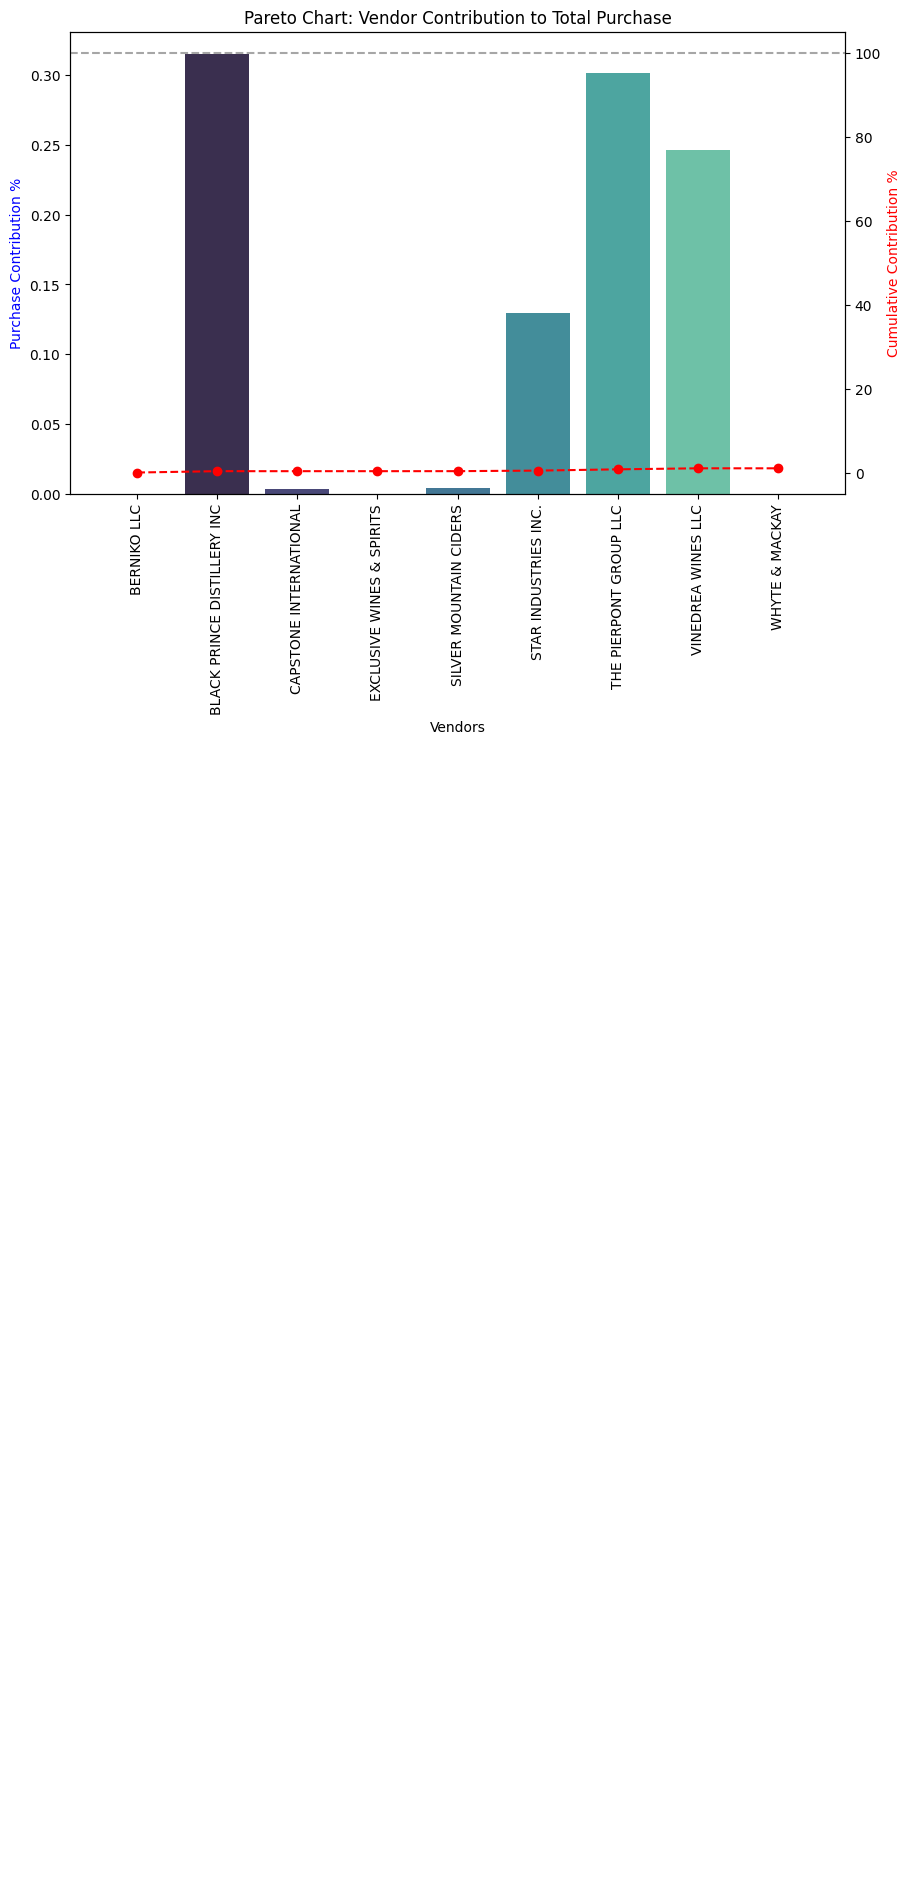

In [33]:
fig, ax1 = plt.subplots(figsize=(10,6))

# agar VendorName index me hai
vendors = top_vendors.index

# Bar plot
sns.barplot(x=vendors, y=top_vendors['PurchaseContribution%'], palette='mako', ax=ax1)

# Text labels
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(round(value,1)) + '%', ha='center', fontsize=10, color='white')

# Line plot
ax2 = ax1.twinx()
ax2.plot(vendors, top_vendors['Cummutive_Contribution'], color='red', marker='o', linestyle='dashed')

# Labels
ax1.set_xticklabels(vendors, rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchase')

# Line at 100%
ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)

plt.show()

How much of total procurement is dependent on the top vendors?


In [34]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

Total Purchase Contribution of top 10 vendors is 1.0 %


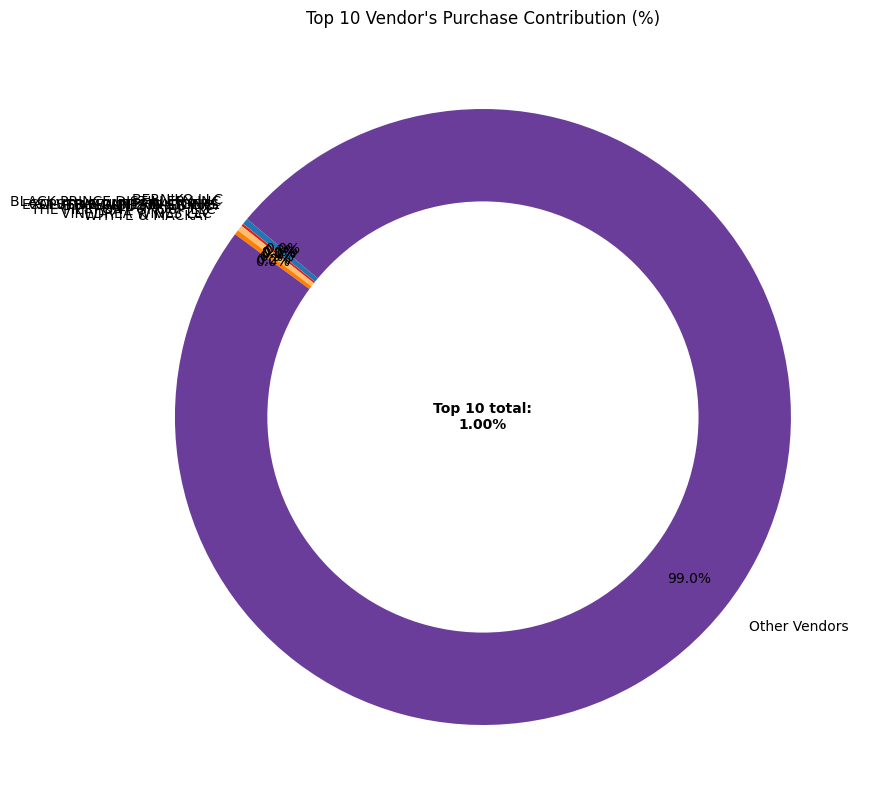

In [35]:
vendors = list(top_vendors.index)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution =  100 - total_contribution

# Append "Other Vendors"
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(15,10))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Donut center circle
center_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(center_circle)

# Center text
plt.text(
    0, 0,
    f"Top 10 total:\n{total_contribution:.2f}%",
    fontsize=10,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

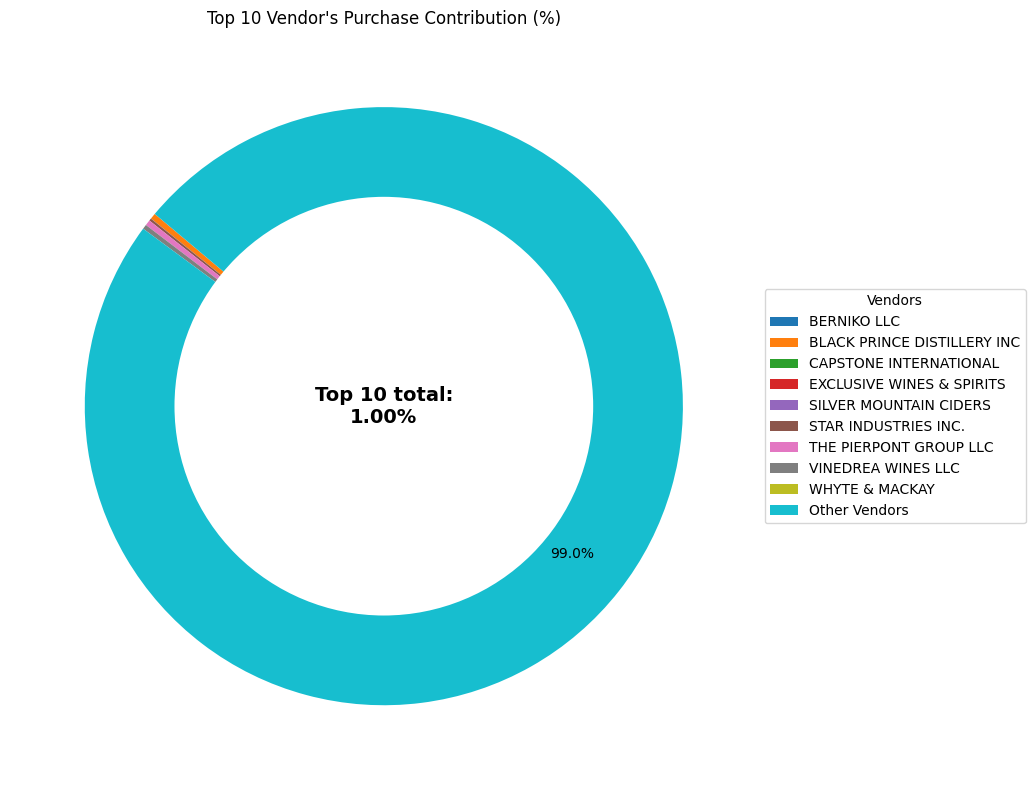

In [36]:
import matplotlib.pyplot as plt

# Step 1: Handle VendorName (index -> column if needed)
if 'VendorName' not in top_vendors.columns:
    vendors = list(top_vendors.index)
else:
    vendors = list(top_vendors['VendorName'])

# Step 2: Correct column name
purchase_contributions = list(top_vendors['PurchaseContribution%'])

# Step 3: Calculate totals safely
total_contribution = sum(purchase_contributions)
remaining_contribution = max(0, 100 - total_contribution)

# Step 4: Add "Other Vendors"
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Step 5: Donut Chart
fig, ax = plt.subplots(figsize=(10,8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=None,  # ❌ remove labels to avoid overlap
    autopct=lambda pct: f'{pct:.1f}%' if pct > 1 else '',  # show only meaningful %
    startangle=140,
    pctdistance=0.8
)

# Step 6: Donut center circle
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Step 7: Center text
plt.text(
    0, 0,
    f"Top 10 total:\n{total_contribution:.2f}%",
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold'
)

# Step 8: Legend (important)
ax.legend(
    wedges,
    vendors,
    title="Vendors",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

# Step 9: Title
plt.title("Top 10 Vendor's Purchase Contribution (%)")

plt.tight_layout()
plt.show()

Does Purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?

In [37]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [38]:
df

,VendorNumber,VendorName,Brand,ActualPrice,Volume,PurchasePrice,Description,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalPurchaseQuantity,TotalPurchaseDollars,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPucharseRatio,UnitPurchasePrice
0,1002,BERNIKO LLC,4015,16.99,750.0,12.87,Ron Fortuna 8 Yr Old Rum,1,16.99,16.99,0.79,0,0.00,0.00,16.99,100.00,0.00,0.00,NaN
1,1439,CAPSTONE INTERNATIONAL,2213,26.99,1750.0,13.66,King Robert II Scotch Whisky,13,246.87,113.94,23.89,4,54.64,0.27,192.23,77.87,3.25,4.52,13.660000
2,2396,BLACK PRINCE DISTILLERY INC,3079,15.99,750.0,10.21,Devils Spring Vodka,717,9360.83,5280.05,564.81,807,5971.94,30.98,3388.89,36.20,0.89,1.57,7.400173
3,8663,STAR INDUSTRIES INC.,2193,24.99,750.0,16.41,Donegal Irish Whiskey,411,7716.89,4430.65,323.87,151,2452.29,12.44,5264.60,68.22,2.72,3.15,16.240331
4,9710,WHYTE & MACKAY,2539,19.99,1750.0,12.30,John Barr Red Scotch Whisky,2,31.98,15.99,3.67,0,0.00,0.00,31.98,100.00,0.00,0.00,NaN
5,9751,VINEDREA WINES LLC,1542,29.99,750.0,22.72,Bowen's American Whiskey,323,8461.77,6397.58,254.74,205,4657.60,24.53,3804.17,44.96,1.58,1.82,22.720000
6,90026,SILVER MOUNTAIN CIDERS,46327,6.99,650.0,4.54,Silver Mtn Hard Cider,47,328.53,202.71,4.64,17,77.18,0.36,251.35,76.51,2.76,4.26,4.540000
7,90034,EXCLUSIVE WINES & SPIRITS,15625,27.99,750.0,18.54,Mourvedre Bunnell Family,2,55.98,27.99,0.22,0,0.00,0.00,55.98,100.00,0.00,0.00,NaN
8,90037,THE PIERPONT GROUP LLC,2163,24.99,750.0,14.38,Sloane's Gin,322,6511.78,4107.98,253.84,580,5713.19,27.98,798.59,12.26,0.56,1.14,9.850328


In [39]:
df["OrderSize"] = pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=['small', 'Medium', 'Large'])


In [40]:
df[["OrderSize","TotalPurchaseQuantity"]]

,OrderSize,TotalPurchaseQuantity
0,small,0
1,Medium,4
2,Large,807
3,Medium,151
4,small,0
5,Large,205
6,Medium,17
7,small,0
8,Large,580


In [41]:
df.groupby("OrderSize")[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
small,NaN
Medium,11.48011
Large,13.32350


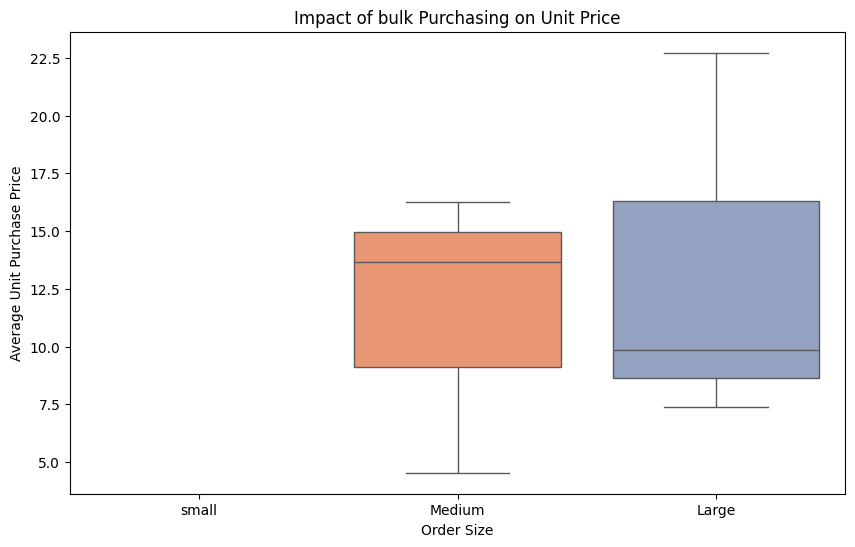

In [42]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='OrderSize',y='UnitPurchasePrice', palette='Set2')
plt.title("Impact of bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

* Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
* The price difference between small and large orders is substantial (~72% reduction in unit cost)
* This suggests that bulk pricing strategies successfully encourage vendors to purchase in large volumes, leading to higher overall sales despite lower per-unit revenue.

Which vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [43]:
df[df['StockTurnover']<1]

,VendorNumber,VendorName,Brand,ActualPrice,Volume,PurchasePrice,Description,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalPurchaseQuantity,TotalPurchaseDollars,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPucharseRatio,UnitPurchasePrice,OrderSize
0,1002,BERNIKO LLC,4015,16.99,750.0,12.87,Ron Fortuna 8 Yr Old Rum,1,16.99,16.99,0.79,0,0.00,0.00,16.99,100.00,0.00,0.00,NaN,small
2,2396,BLACK PRINCE DISTILLERY INC,3079,15.99,750.0,10.21,Devils Spring Vodka,717,9360.83,5280.05,564.81,807,5971.94,30.98,3388.89,36.20,0.89,1.57,7.400173,Large
4,9710,WHYTE & MACKAY,2539,19.99,1750.0,12.30,John Barr Red Scotch Whisky,2,31.98,15.99,3.67,0,0.00,0.00,31.98,100.00,0.00,0.00,NaN,small
7,90034,EXCLUSIVE WINES & SPIRITS,15625,27.99,750.0,18.54,Mourvedre Bunnell Family,2,55.98,27.99,0.22,0,0.00,0.00,55.98,100.00,0.00,0.00,NaN,small
8,90037,THE PIERPONT GROUP LLC,2163,24.99,750.0,14.38,Sloane's Gin,322,6511.78,4107.98,253.84,580,5713.19,27.98,798.59,12.26,0.56,1.14,9.850328,Large


In [44]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending= True).head(10)

,StockTurnover
VendorName,
BERNIKO LLC,0.00
EXCLUSIVE WINES & SPIRITS,0.00
WHYTE & MACKAY,0.00
THE PIERPONT GROUP LLC,0.56
BLACK PRINCE DISTILLERY INC,0.89


How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [45]:
df['UnsoldInventoryValue'] = df['TotalPurchaseQuantity'] - df['TotalSalesDollars'] * df['PurchasePrice']
print('Total Unsold Capital:' , format_dollars(df['UnsoldInventoryValue'].sum()))

Total Unsold Capital: -512848.7049


In [46]:
# Aggregate Capital Locked per Vendor

inventory_value_per_vendor = df.groupby('VendorName')['UnsoldInventoryValue'].sum().reset_index()

#sort vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by='UnsoldInventoryValue', ascending= False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
0,BERNIKO LLC,-218.66129999999995
8,WHYTE & MACKAY,-393.35400000000004
3,EXCLUSIVE WINES & SPIRITS,-1037.8691999999999
4,SILVER MOUNTAIN CIDERS,-1474.5261999999998
2,CAPSTONE INTERNATIONAL,-3368.2442
6,THE PIERPONT GROUP LLC,-93059.3964
1,BLACK PRINCE DISTILLERY INC,-94767.07430000001
5,STAR INDUSTRIES INC.,-126483.1649
7,VINEDREA WINES LLC,-192046.4144


What is the 95% confidance intervals for profit margins of top-performing and low-performing vendors.

In [47]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

In [48]:
top_threshold

np.float64(7716.89)

In [49]:
low_threshold

np.float64(55.98)

In [50]:
 top_vendors = df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
 low_vendors = df[df['TotalSalesDollars'] >= low_threshold]['ProfitMargin'].dropna()

In [51]:
low_vendors

1     77.87
2     36.20
3     68.22
5     44.96
6     76.51
7    100.00
8     12.26
Name: ProfitMargin, dtype: float64

In [59]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # Standard Error
    t_critical = stats.t.ppf((1 + confidence) / 2 , df= len(data) -1 )
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error
    

Top vendors 95% CI: ( 8.69,  90.90), Mean:  49.79
Low vendors 95% CI: ( 31.87,  86.99), Mean:  59.43


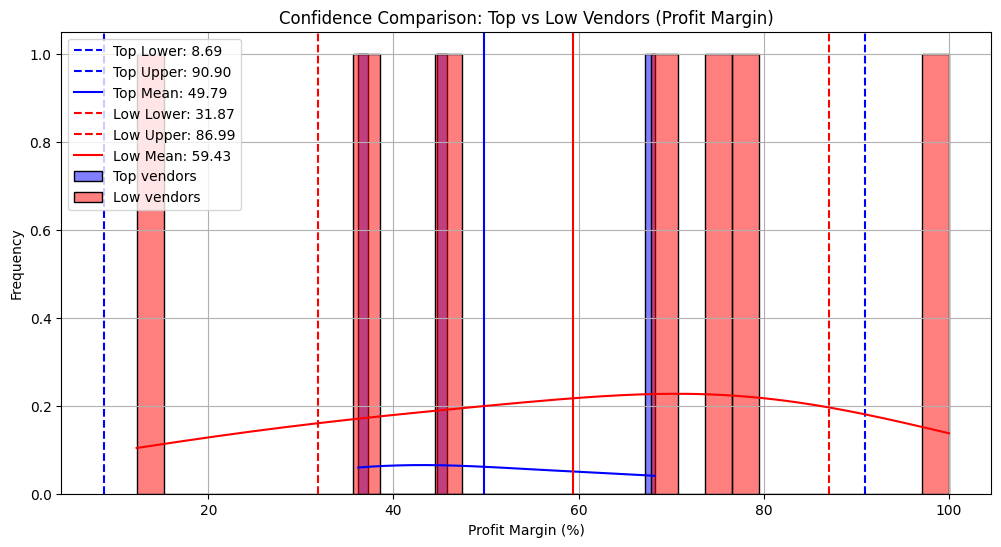

In [60]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top vendors 95% CI: ({top_lower: .2f}, {top_upper: .2f}), Mean: {top_mean: .2f}")
print(f"Low vendors 95% CI: ({low_lower: .2f}, {low_upper: .2f}), Mean: {low_mean: .2f}")

plt.figure(figsize =(12,6))

# top Vendor Plot
sns.histplot(top_vendors, kde=True, color='blue', bins= 30, alpha= 0.5, label= 'Top vendors')
plt.axvline(top_lower, color='blue', linestyle='--', label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color='blue', linestyle='--', label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color='blue', linestyle='-', label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color='red', bins= 30, alpha= 0.5, label= 'Low vendors')
plt.axvline(low_lower, color='red', linestyle='--', label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color='red', linestyle='--', label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color='red', linestyle='-', label=f"Low Mean: {low_mean:.2f}")

#Finalize Plot
plt.title("Confidence Comparison: Top vs Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


* The confidence interval for low_performing vendors (31.87% to 86.99%) is significantly higher than that of top_performing vendors (8.69% to 90.90%).
* This suggests that vendors with lower sales tend to maintain highr profit margins, potensially due to premium pricing or lower operational costs.
* For High-Performing Vendors: If they aim to improve profitability, they could selective price adjustments, cost optimization, or bundling strategies.
* For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distributiob strategies.

Is there a significant difference in profit margins between top-performing and low-performing vendors?
* Hypothesis:
   * H0 (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.
   * H1 (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [61]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)


top_vendors = df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors = df[df['TotalSalesDollars'] >= low_threshold]['ProfitMargin'].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var= False)

# Print resuls
print(f"T-Statistics: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H0: There is a significant difference in proifit between top and low performing vendors.")
else:
    print("Fail to reject H0: No significant difference in profit margins.")




T-Statistics: -0.6525, P-Value: 0.5350
Fail to reject H0: No significant difference in profit margins.
